# 02 Exploratory Data Analysis

This notebook explores inspection distributions, trends over time, score behavior, and borough-level patterns in the filtered 2022 to 2025 data.

In [1]:
# Author: Jessica
# Loading cleaned data so this notebook runs independently

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_filtered_2022_2025 = pd.read_csv("shared_data/cleaned_inspections.csv", parse_dates=['INSPECTION DATE'])
print(df_filtered_2022_2025.shape)
df_filtered_2022_2025.head()

(258107, 27)


,CAMIS,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE DESCRIPTION,INSPECTION DATE,ACTION,...,INSPECTION TYPE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL,NTA,Location
0,40387418,TAL BAGELS DELI,Manhattan,975979,FIRST AVENUE,NaN,2127539080,Bagels/Pretzels,2025-05-27,Violations were cited in the following area(s).,...,Cycle Inspection / Initial Inspection,0.0,0.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN
1,40741728,WALLSE,Manhattan,342344,WEST 11 STREET,NaN,2123522300,Continental,2023-05-02,Violations were cited in the following area(s).,...,Cycle Inspection / Initial Inspection,0.0,0.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN
2,41701450,CIBO EXPRESS FOOD COURT (CONCOURSE D),Queens,NaN,LAGUARDIA AIRPORT,11369.0,9296230872,Sandwiches,2024-10-30,No violations were recorded at the time of thi...,...,Cycle Inspection / Initial Inspection,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,50131935,Beacon,Queens,NaN,Airport Terminal 4 CA11,11432.0,4706221735,American,2025-05-28,Violations were cited in the following area(s).,...,Pre-permit (Operational) / Initial Inspection,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,50121182,DELUCA ITALIAN RESTAURANT,0,7324,AMBOY RD,10307.0,3476725335,Italian,2024-01-22,Violations were cited in the following area(s).,...,Cycle Inspection / Initial Inspection,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


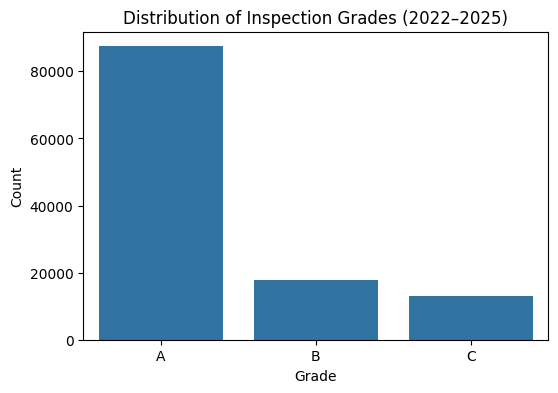

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(data=df_filtered_2022_2025, x="GRADE", order=["A","B","C"])

plt.title("Distribution of Inspection Grades (2022–2025)")
plt.xlabel("Grade")
plt.ylabel("Count")

plt.show()

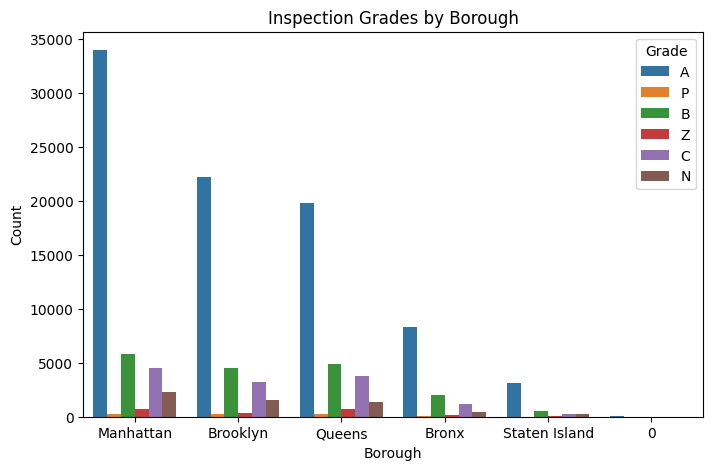

In [3]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_filtered_2022_2025,
    x="BORO",
    hue="GRADE",
    order=df_filtered_2022_2025["BORO"].value_counts().index
)

plt.title("Inspection Grades by Borough")
plt.xlabel("Borough")
plt.ylabel("Count")
plt.legend(title="Grade")

plt.show()

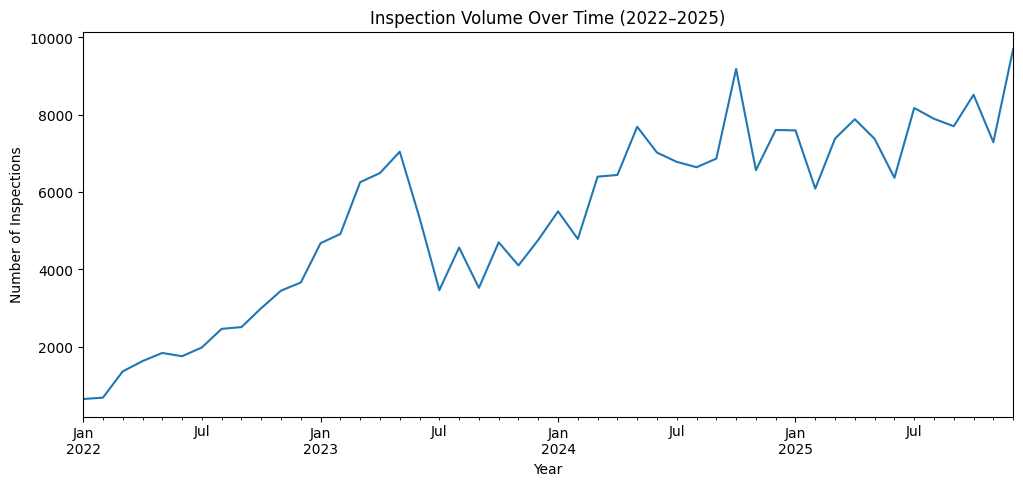

In [4]:
df_filtered_2022_2025["YearMonth"] = df_filtered_2022_2025["INSPECTION DATE"].dt.to_period("M")

monthly = df_filtered_2022_2025.groupby("YearMonth")["CAMIS"].count()

plt.figure(figsize=(12,5))
monthly.plot()

plt.title("Inspection Volume Over Time (2022–2025)")
plt.xlabel("Year")
plt.ylabel("Number of Inspections")

plt.show()

/tmp/ipykernel_25025/2833399416.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


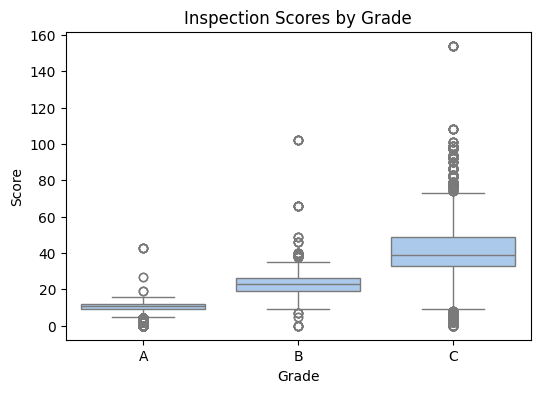

In [5]:
plt.figure(figsize=(6,4))

# lighten the boxplot by using a pastel version of the default blue
sns.boxplot(
    data=df_filtered_2022_2025,
    x="GRADE",
    y="SCORE",
    order=["A","B","C"],
    palette=[sns.color_palette("pastel")[0]]*3  # same light blue for each grade
)

plt.title("Inspection Scores by Grade")
plt.xlabel("Grade")
plt.ylabel("Score")

plt.show()

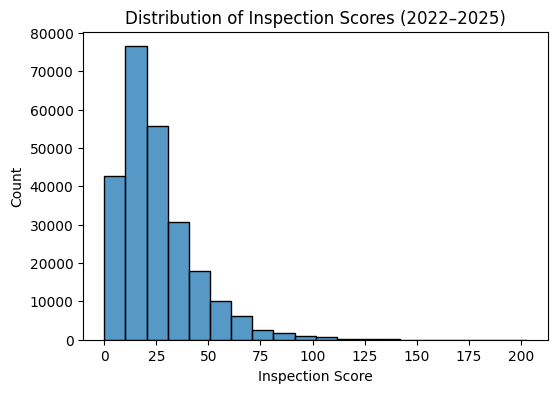

In [6]:
#Histogram of Score distribution (styled like the grade countplot)
plt.figure(figsize=(6,4))

# use seaborn histogram for consistent styling
sns.histplot(
    data=df_filtered_2022_2025,
    x="SCORE",
    bins=20,
    color=sns.color_palette()[0],  # default seaborn blue
    edgecolor="black",
    kde=False,
)

plt.title("Distribution of Inspection Scores (2022–2025)")
plt.xlabel("Inspection Score")
plt.ylabel("Count")

plt.show()

In [7]:
df_filtered_2022_2025['BORO'].unique()

df_Manhattan = df_filtered_2022_2025[
    df_filtered_2022_2025['BORO'] == 'Manhattan'
].copy()

df_Manhattan.describe()

,CAMIS,ZIPCODE,INSPECTION DATE,SCORE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL
count,9.518800e+04,93860.000000,95188,90431.000000,94746.000000,94746.000000,93418.000000,93422.000000,93422.000000,9.304200e+04,9.474600e+04
mean,4.795198e+07,10022.520072,2024-06-02 08:58:26.963062,24.356261,40.182810,-72.944444,105.082200,3.648948,10047.375425,1.037257e+06,9.915407e+08
min,3.019184e+07,10000.000000,2022-01-03 00:00:00,0.000000,0.000000,-74.018001,101.000000,1.000000,201.000000,1.000000e+06,1.000000e+00
25%,5.000153e+07,10010.000000,2023-07-18 00:00:00,12.000000,40.727717,-73.995173,103.000000,2.000000,4700.000000,1.010667e+06,1.004800e+09
50%,5.008947e+07,10017.000000,2024-07-20 12:00:00,20.000000,40.749641,-73.985607,105.000000,3.000000,9200.000000,1.028626e+06,1.008570e+09
75%,5.012768e+07,10027.000000,2025-04-17 00:00:00,32.000000,40.765983,-73.970811,107.000000,4.000000,13400.000000,1.061879e+06,1.013010e+09
max,5.018002e+07,11371.000000,2025-12-31 00:00:00,203.000000,40.872885,0.000000,164.000000,10.000000,31704.000000,1.799161e+06,1.270000e+09
std,3.835777e+06,31.039181,NaN,18.589266,4.791123,8.697200,3.020658,2.377640,6749.263333,3.610467e+04,1.345077e+08


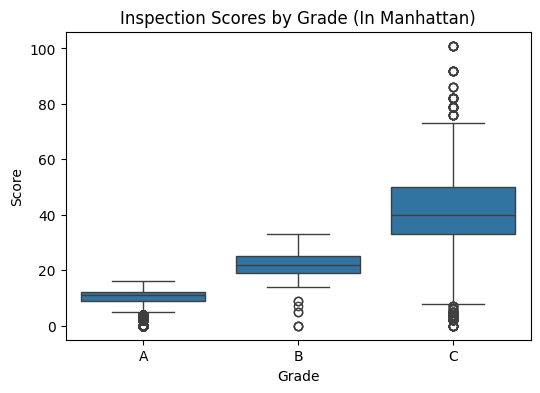

In [8]:
#Grading in Manhattan


plt.figure(figsize=(6,4))

sns.boxplot(
    data=df_Manhattan,
    x="GRADE",
    y="SCORE",
    order=["A","B","C"]
)

plt.title("Inspection Scores by Grade (In Manhattan)")
plt.xlabel("Grade")
plt.ylabel("Score")

plt.show()
#Showing the boxplot throughout the years

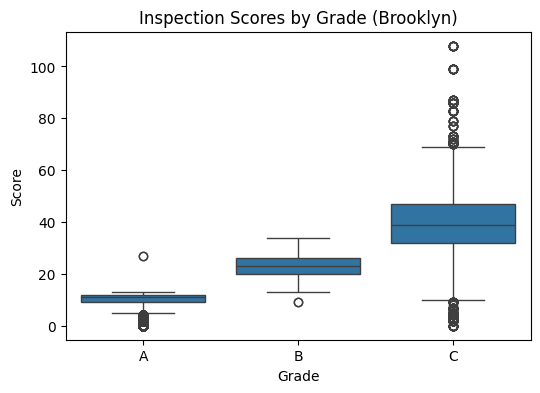

In [9]:
# checking borough values
df_filtered_2022_2025['BORO'].unique()

# filtering for Brooklyn
df_Brooklyn = df_filtered_2022_2025[
    df_filtered_2022_2025['BORO'].str.upper() == 'BROOKLYN'
].copy()

df_Brooklyn.describe()

# plotting
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df_Brooklyn,
    x="GRADE",
    y="SCORE",
    order=["A","B","C"]
)

plt.title("Inspection Scores by Grade (Brooklyn)")
plt.xlabel("Grade")
plt.ylabel("Score")

plt.show()

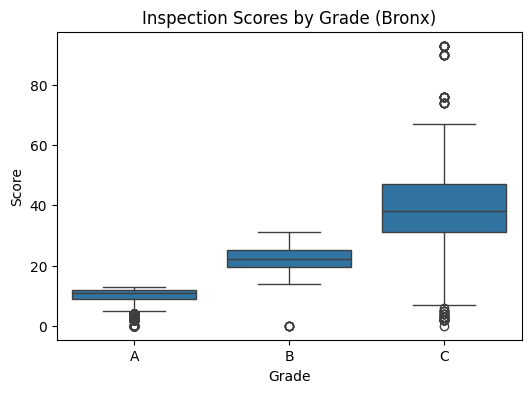

In [10]:

# checking borough values
df_filtered_2022_2025['BORO'].unique()

# filtering for Bronx
df_Bronx = df_filtered_2022_2025[
    df_filtered_2022_2025['BORO'].str.upper() == 'BRONX'
].copy()

df_Bronx.describe()

# plotting
plt.figure(figsize=(6,4))

sns.boxplot(
    data=df_Bronx,
    x="GRADE",
    y="SCORE",
    order=["A","B","C"]
)

plt.title("Inspection Scores by Grade (Bronx)")
plt.xlabel("Grade")
plt.ylabel("Score")

plt.show()

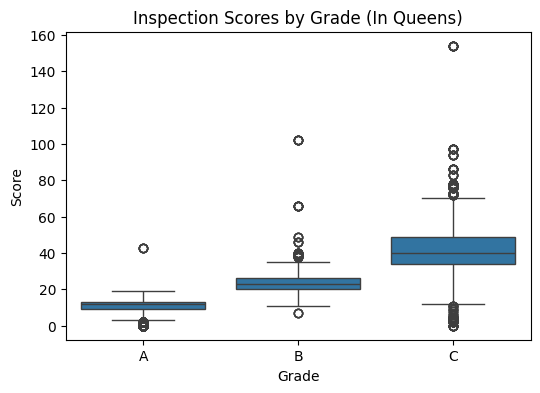

In [11]:
df_filtered_2022_2025.BORO.unique()
df_Queens = df_filtered_2022_2025[df_filtered_2022_2025['BORO'] == 'Queens'].copy()
df_Queens.describe()

plt.figure(figsize=(6,4))

sns.boxplot(
    data=df_Queens,
    x="GRADE",
    y="SCORE",
    order=["A","B","C"]
)

plt.title("Inspection Scores by Grade (In Queens)")
plt.xlabel("Grade")
plt.ylabel("Score")

plt.show()

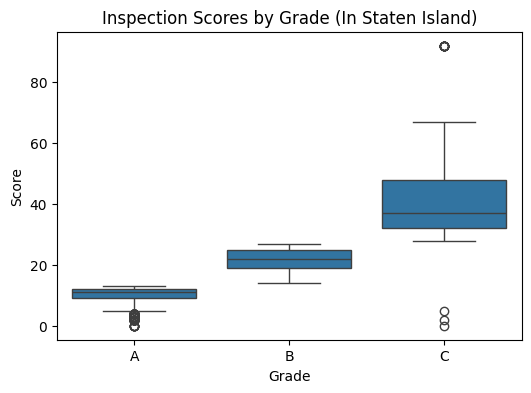

In [12]:
df_filtered_2022_2025.BORO.unique()
df_Staten_Island = df_filtered_2022_2025[df_filtered_2022_2025['BORO'] == 'Staten Island'].copy()
df_Staten_Island.describe()

plt.figure(figsize=(6,4))

sns.boxplot(
    data=df_Staten_Island,
    x="GRADE",
    y="SCORE",
    order=["A","B","C"]
)

plt.title("Inspection Scores by Grade (In Staten Island)")
plt.xlabel("Grade")
plt.ylabel("Score")

plt.show()